In [10]:
import os
import cv2

# 🔹 CONFIGURACIÓN
BASE_PATH = "css-data"
OUTPUT_DIR = "dataset_clasificacion"

CLASSES = ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle'] # ajusta según tu dataset


def yolo_to_bbox(x_center, y_center, width, height, img_w, img_h):
    x_center *= img_w
    y_center *= img_h
    width *= img_w
    height *= img_h

    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)
    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)

    return x1, y1, x2, y2


def process_split(split):
    img_dir = os.path.join(BASE_PATH, split, "images")
    label_dir = os.path.join(BASE_PATH, split, "labels")
    output_split = os.path.join(OUTPUT_DIR, split)

    os.makedirs(output_split, exist_ok=True)

    count = 0

    for file in os.listdir(img_dir):
        if not file.endswith((".jpg", ".png", ".jpeg")):
            continue

        img_path = os.path.join(img_dir, file)
        label_path = os.path.join(label_dir, os.path.splitext(file)[0] + ".txt")

        if not os.path.exists(label_path):
            continue

        image = cv2.imread(img_path)
        if image is None:
            continue

        h, w, _ = image.shape

        with open(label_path, "r") as f:
            lines = f.readlines()

        for i, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            x, y, bw, bh = map(float, parts[1:])

            x1, y1, x2, y2 = yolo_to_bbox(x, y, bw, bh, w, h)

            # límites válidos
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            crop = image[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            # 🔹 (opcional pero recomendado)
            crop = cv2.resize(crop, (224, 224))

            class_name = CLASSES[class_id]
            class_dir = os.path.join(output_split, class_name)
            os.makedirs(class_dir, exist_ok=True)

            output_path = os.path.join(class_dir, f"{file[:-4]}_{i}.jpg")

            cv2.imwrite(output_path, crop)
            count += 1

    print(f"{split}: {count} imágenes generadas")


def main():
    for split in ["train", "valid"]:
        process_split(split)


if __name__ == "__main__":
    main()

train: 36895 imágenes generadas
valid: 697 imágenes generadas


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 🔹 CONFIGURACIÓN
DATASET_DIR = "dataset_clasificacion"
BATCH_SIZE = 32
EPOCHS = 15
LR = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cuda


In [22]:

# 🔹 TRANSFORMACIONES
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# 🔹 DATASETS
train_dataset = datasets.ImageFolder(root=f"{DATASET_DIR}/train", transform=transform)
val_dataset = datasets.ImageFolder(root=f"{DATASET_DIR}/valid", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(train_dataset.classes)
print("Clases:", train_dataset.classes)

Clases: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


In [23]:



# 🧠 MODELO (igual al anterior)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        self.fc1 = nn.Linear(128 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))

        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# 🔹 INICIALIZACIÓN
model = SimpleCNN(num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# 🔹 FUNCIÓN DE VALIDACIÓN
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    return loss_total / len(loader), acc

# 🔹 ENTRENAMIENTO
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print("-" * 40)

# 💾 GUARDAR MODELO
torch.save(model.state_dict(), "modelo_cnn.pth")
print("Modelo guardado como modelo_cnn.pth")

Epoch [1/15]
Train Loss: 1.6748
Val Loss: 1.4603 | Val Acc: 52.51%
----------------------------------------
Epoch [2/15]
Train Loss: 1.4733
Val Loss: 1.3061 | Val Acc: 53.66%
----------------------------------------
Epoch [3/15]
Train Loss: 1.3816
Val Loss: 1.1308 | Val Acc: 63.41%
----------------------------------------
Epoch [4/15]
Train Loss: 1.3045
Val Loss: 1.1734 | Val Acc: 60.11%
----------------------------------------
Epoch [5/15]
Train Loss: 1.2619
Val Loss: 1.0387 | Val Acc: 64.13%
----------------------------------------
Epoch [6/15]
Train Loss: 1.2025
Val Loss: 1.0027 | Val Acc: 66.86%
----------------------------------------
Epoch [7/15]
Train Loss: 1.1657
Val Loss: 1.0919 | Val Acc: 64.28%
----------------------------------------
Epoch [8/15]
Train Loss: 1.1259
Val Loss: 1.0074 | Val Acc: 66.00%
----------------------------------------
Epoch [9/15]
Train Loss: 1.0857
Val Loss: 1.0001 | Val Acc: 67.29%
----------------------------------------
Epoch [10/15]
Train Loss: 1.

In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader, classes):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 🔹 Matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)

    print("Matriz de confusión:")
    print(cm)

    # 🔹 Visualización
    plt.figure()
    plt.imshow(cm)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    plt.xlabel("Predicción")
    plt.ylabel("Real")

    # 🔹 Mostrar valores en la matriz
    for i in range(len(classes)):
        for j in range(len(classes)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()


Matriz de confusión:
[[ 55   1   4   5   5   3   0   5   0   1]
 [  1  15   0   1   3   0   0   0   0   1]
 [  3   0  55   0   3   3   1   0   1   3]
 [  4   0   6  56   3   2   2   0   0   1]
 [  4   1   3   2  54  26   1   3  10   2]
 [  4   0   2   2   2 130   2   5  17   2]
 [  1   0   0   0   0   1  40   2   0   0]
 [  2   0   0   1   4   9   1  22   1   1]
 [  0   0   0   0   0   5   0   0  49   1]
 [  4   0   2   0   0   4   1   0   5  26]]


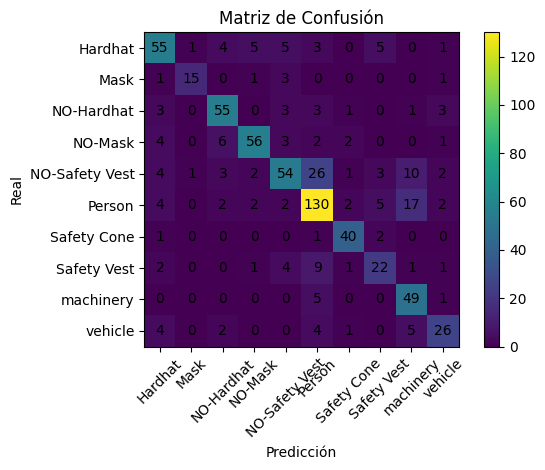

In [25]:
plot_confusion_matrix(model, val_loader, train_dataset.classes)